Loading FBXW7...
Loading MYC...
Loading NICD...


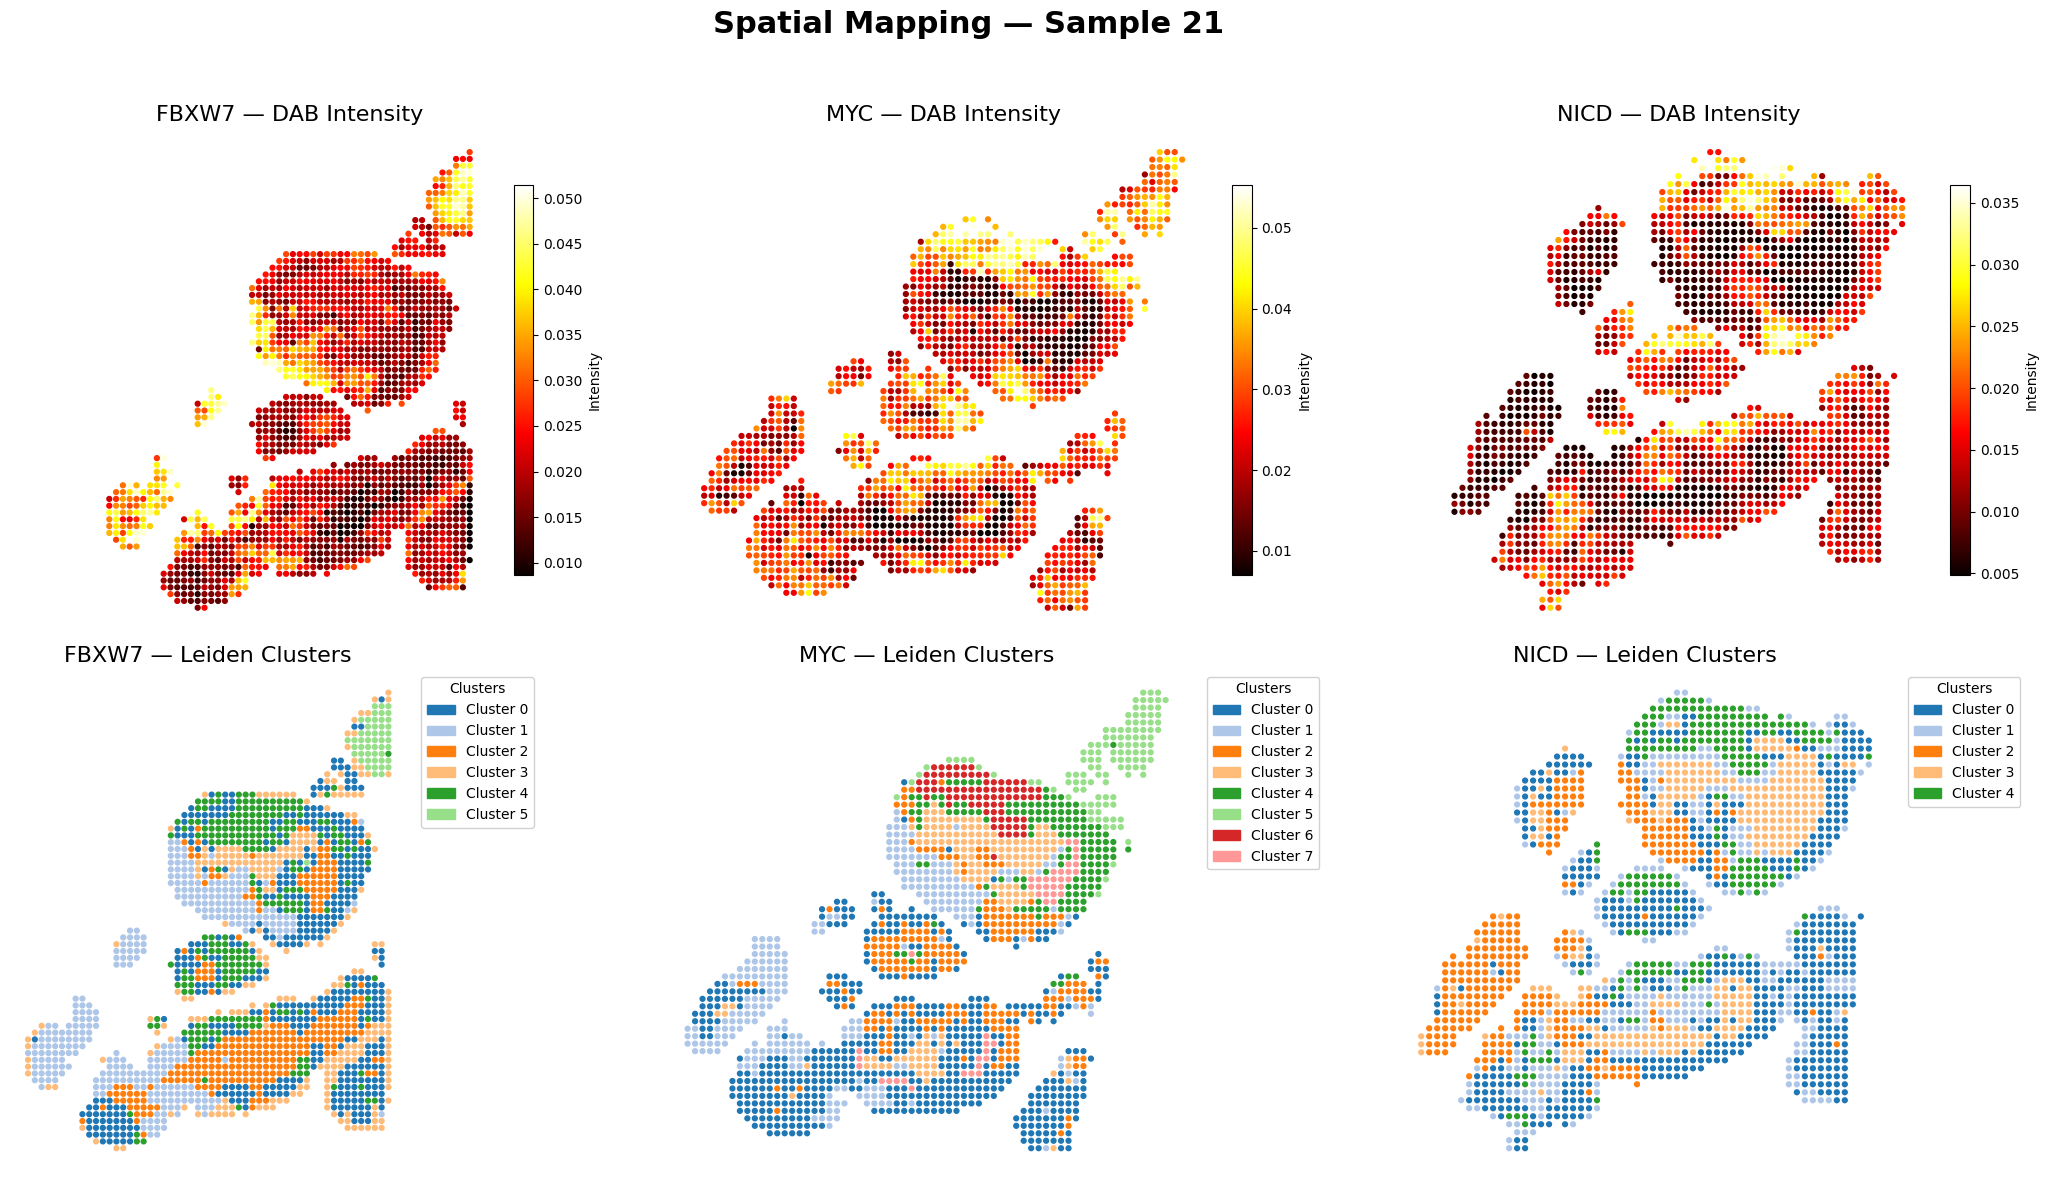

✅ Saved plot to: /Users/lollija/phd/fbxw7/plots/spatial_maps_sample_21.png


In [115]:
import os
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Setup & Paths                                                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
OUTPUT_DIR = "/Users/lollija/phd/fbxw7/results_per_sample"
PLOT_DIR   = "/Users/lollija/phd/fbxw7/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

SAMPLE_ID = "21"
MARKERS   = ["FBXW7", "MYC", "NICD"]

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Plotting Logic                                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(22, 12))
fig.suptitle(f"Spatial Mapping — Sample {SAMPLE_ID}", fontsize=22, fontweight="bold", y=0.98)

# We use tab20 for a broad palette of distinct categorical colors
cmap_clusters = plt.colormaps.get_cmap('tab20')

for i, marker in enumerate(MARKERS):
    adata_path = os.path.join(OUTPUT_DIR, f"adata_{SAMPLE_ID}_{marker}.h5ad")
    
    # 1. Handle missing files safely
    if not os.path.exists(adata_path):
        print(f"⚠️ Missing: {adata_path}")
        axes[0, i].axis('off')
        axes[1, i].axis('off')
        axes[0, i].set_title(f"{marker}\nData Not Found", color="red")
        continue
        
    print(f"Loading {marker}...")
    adata = ad.read_h5ad(adata_path)
    
    # 2. Extract Coordinates (Inverting Y so top-left is 0,0 like an image)
    x = adata.obs["x"].values
    y = -adata.obs["y"].values
    
    # 3. Plot Row 1: DAB Intensity
    dab = adata.obs["dab"].values
    p1, p99 = np.percentile(dab, [1, 99]) # Clip extreme outliers for better contrast
    
    sc1 = axes[0, i].scatter(x, y, c=np.clip(dab, p1, p99), cmap="hot", s=12, rasterized=True)
    axes[0, i].set_title(f"{marker} — DAB Intensity", fontsize=16)
    axes[0, i].set_aspect('equal')
    axes[0, i].axis('off')
    plt.colorbar(sc1, ax=axes[0, i], fraction=0.03, pad=0.04, label="Intensity")
    
    # 4. Plot Row 2: Leiden Clusters
    leiden_cat = adata.obs["leiden"].astype('category')
    categories = leiden_cat.cat.categories
    
    # Generate discrete colors mapped to cluster numbers
    colors = [cmap_clusters(int(c) % 20) for c in categories]
    color_map = dict(zip(categories, colors))
    c_mapped = [color_map[c] for c in leiden_cat]
    
    sc2 = axes[1, i].scatter(x, y, c=c_mapped, s=12, rasterized=True)
    axes[1, i].set_title(f"{marker} — Leiden Clusters", fontsize=16)
    axes[1, i].set_aspect('equal')
    axes[1, i].axis('off')
    
    # Create nice legend handles
    handles = [mpatches.Patch(color=color_map[c], label=f"Cluster {c}") for c in categories]
    
    # Adjust legend position based on how many clusters there are
    ncol = 2 if len(categories) > 10 else 1
    axes[1, i].legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', 
                      fontsize=10, framealpha=0.9, title="Clusters", ncol=ncol)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Leave room for suptitle
out_path = os.path.join(PLOT_DIR, f"spatial_maps_sample_{SAMPLE_ID}.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Saved plot to: {out_path}")

Loading FBXW7...
Loading MYC...
Loading NICD...


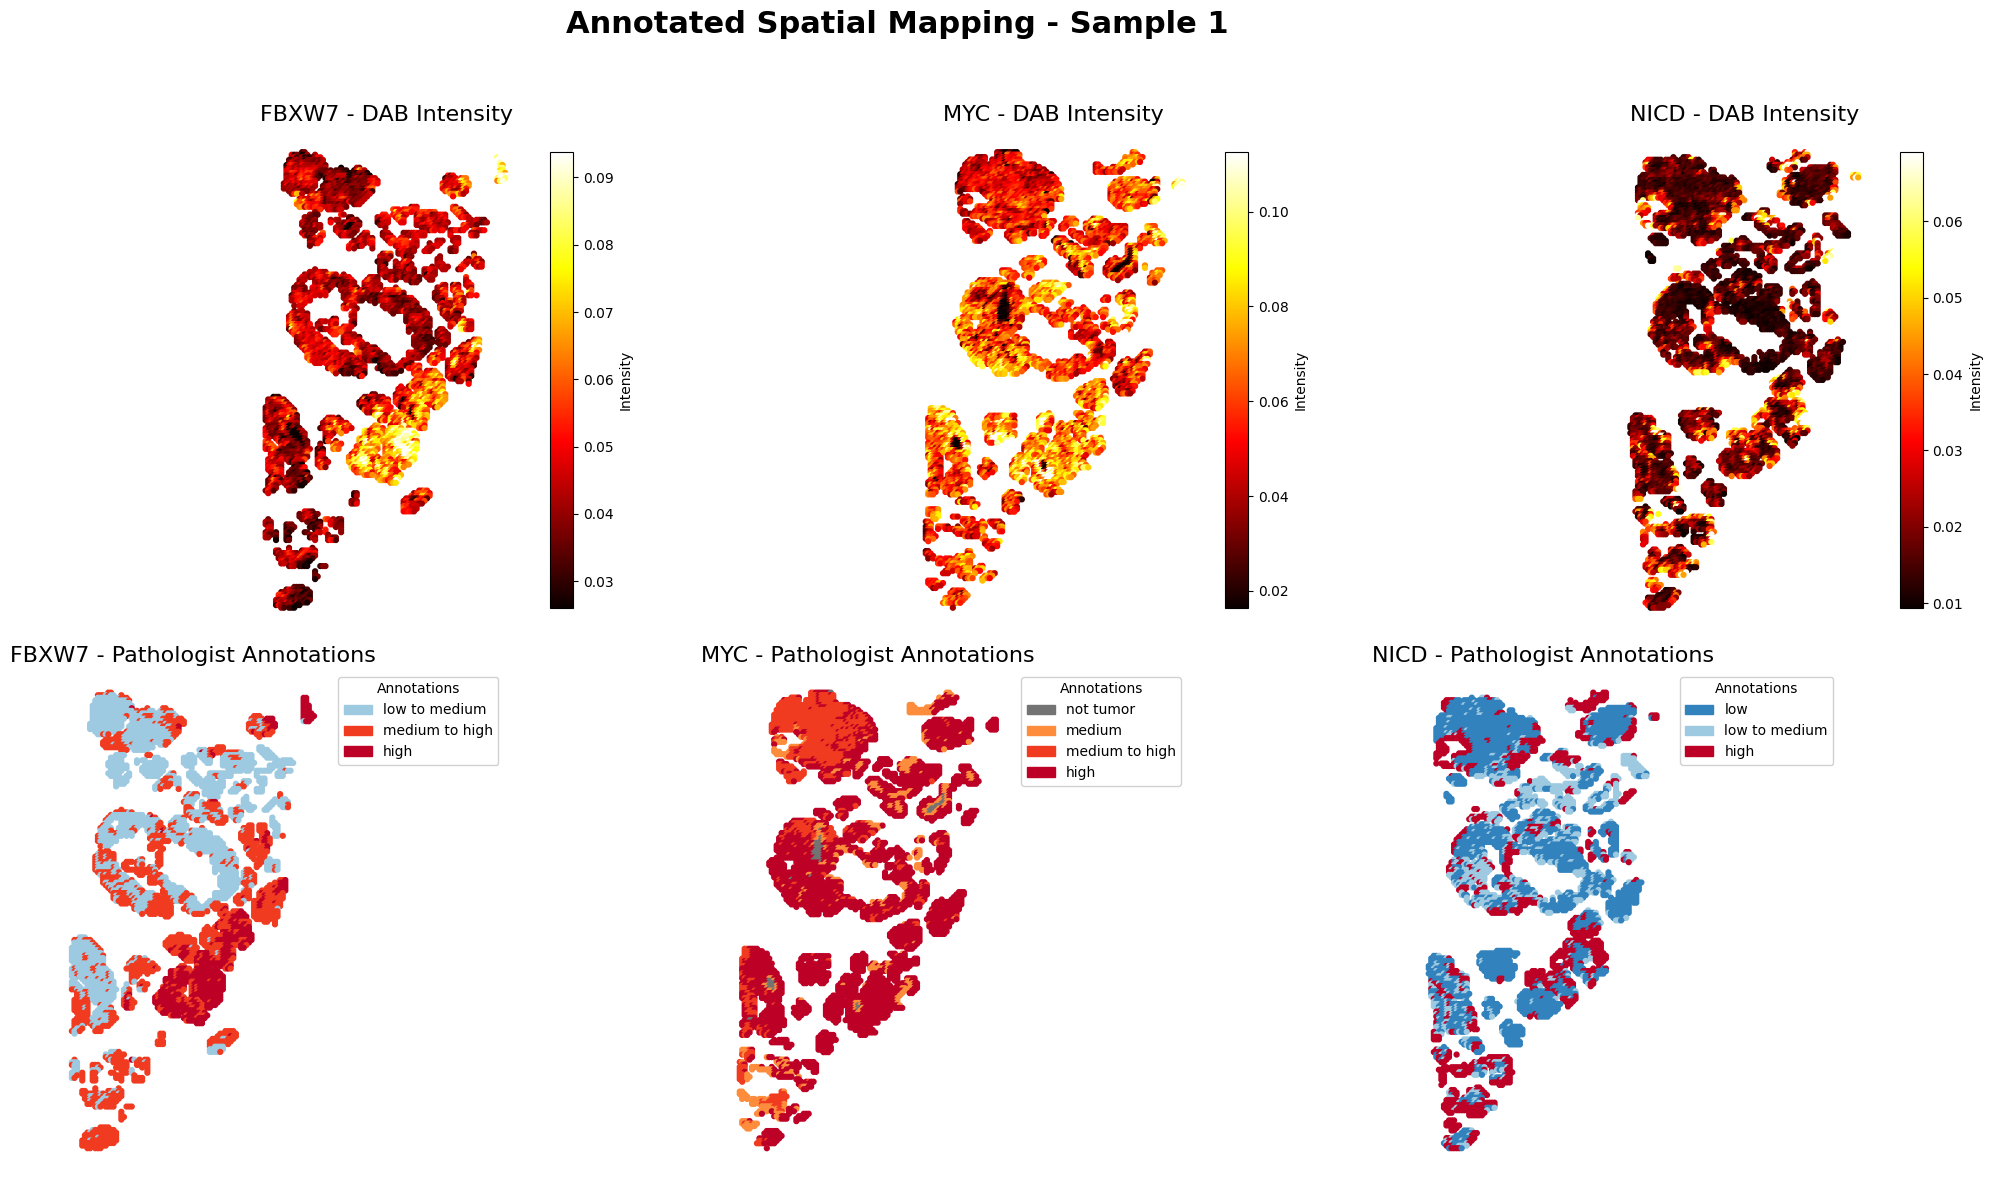

Saved plot to: /Users/lollija/phd/fbxw7/plots/spatial_maps_annotations_sample_1.png


In [120]:
import os

import anndata as ad
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np


OUTPUT_DIR = "/Users/lollija/phd/fbxw7/results_per_sample"
PLOT_DIR = "/Users/lollija/phd/fbxw7/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

SAMPLE_ID = "1"
MARKERS = ["FBXW7", "MYC", "NICD"]

ANNOTATION_COLORS = {
    "unannotated": "#d3d3d3",
    "not tumor": "#737373",
    "low": "#3182bd",
    "low to medium": "#9ecae1",
    "medium": "#fd8d3c",
    "medium to high": "#f03b20",
    "high": "#bd0026",
    "mixed": "#756bb1",
}


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(22, 12))
fig.suptitle(
    f"Annotated Spatial Mapping - Sample {SAMPLE_ID}",
    fontsize=22,
    fontweight="bold",
    y=0.98,
)

for i, marker in enumerate(MARKERS):
    adata_path = os.path.join(OUTPUT_DIR, f"adata_{SAMPLE_ID}_{marker}.h5ad")

    if not os.path.exists(adata_path):
        print(f"Missing: {adata_path}")
        axes[0, i].axis("off")
        axes[1, i].axis("off")
        axes[0, i].set_title(f"{marker}\nData Not Found", color="red")
        continue

    print(f"Loading {marker}...")
    adata = ad.read_h5ad(adata_path)

    x = adata.obs["x"].values
    y = -adata.obs["y"].values

    dab = adata.obs["dab"].values
    p1, p99 = np.percentile(dab, [1, 99])

    sc1 = axes[0, i].scatter(
        x,
        y,
        c=np.clip(dab, p1, p99),
        cmap="hot",
        s=12,
        rasterized=True,
    )
    axes[0, i].set_title(f"{marker} - DAB Intensity", fontsize=16)
    axes[0, i].set_aspect("equal")
    axes[0, i].axis("off")
    plt.colorbar(sc1, ax=axes[0, i], fraction=0.03, pad=0.04, label="Intensity")

    if "annotation" not in adata.obs.columns:
        print(f"No annotation column found for {marker}; showing all patches as unannotated.")
        annotations = np.array(["unannotated"] * adata.n_obs)
    else:
        annotations = adata.obs["annotation"].astype(str).values

    c_mapped = [ANNOTATION_COLORS.get(value, "#d3d3d3") for value in annotations]

    axes[1, i].scatter(x, y, c=c_mapped, s=12, rasterized=True)
    axes[1, i].set_title(f"{marker} - Pathologist Annotations", fontsize=16)
    axes[1, i].set_aspect("equal")
    axes[1, i].axis("off")

    present_annotations = set(annotations)
    ordered_annotations = [
        label for label in ANNOTATION_COLORS if label in present_annotations
    ]

    handles = [
        mpatches.Patch(color=ANNOTATION_COLORS[label], label=label)
        for label in ordered_annotations
    ]
    if handles:
        axes[1, i].legend(
            handles=handles,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=10,
            framealpha=0.9,
            title="Annotations",
        )

plt.tight_layout(rect=[0, 0, 1, 0.95])
out_path = os.path.join(PLOT_DIR, f"spatial_maps_annotations_sample_{SAMPLE_ID}.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved plot to: {out_path}")


Processing per-sample annotations for FBXW7...

Patch Count Summary per Per-Sample Annotation (FBXW7):

sample             1   12   13    16    19     2    20   21    22    24   26    3   39    52    58     7  Total_Patches
annotation                                                                                                             
unannotated        0    0    0    43     0    45     0    0   265     0    0    0    0     0     0    36            389
not tumor          0   76   49     0   571  1315   193  528   543    76  182    0  599    78     0   539           4749
low                0    0  369     0     0     0     0  442     0     0    0    0    0     0     0  1970           2781
low to medium   2010    0    0  1719   525     0     0  237     0    22    0    0  488     0     0     0           5001
medium             0    0  588  4005     0     0  1846    0     0   291  318  192    0  1591     0   810           9641
medium to high  1642  584  566     0  1212   925   646  

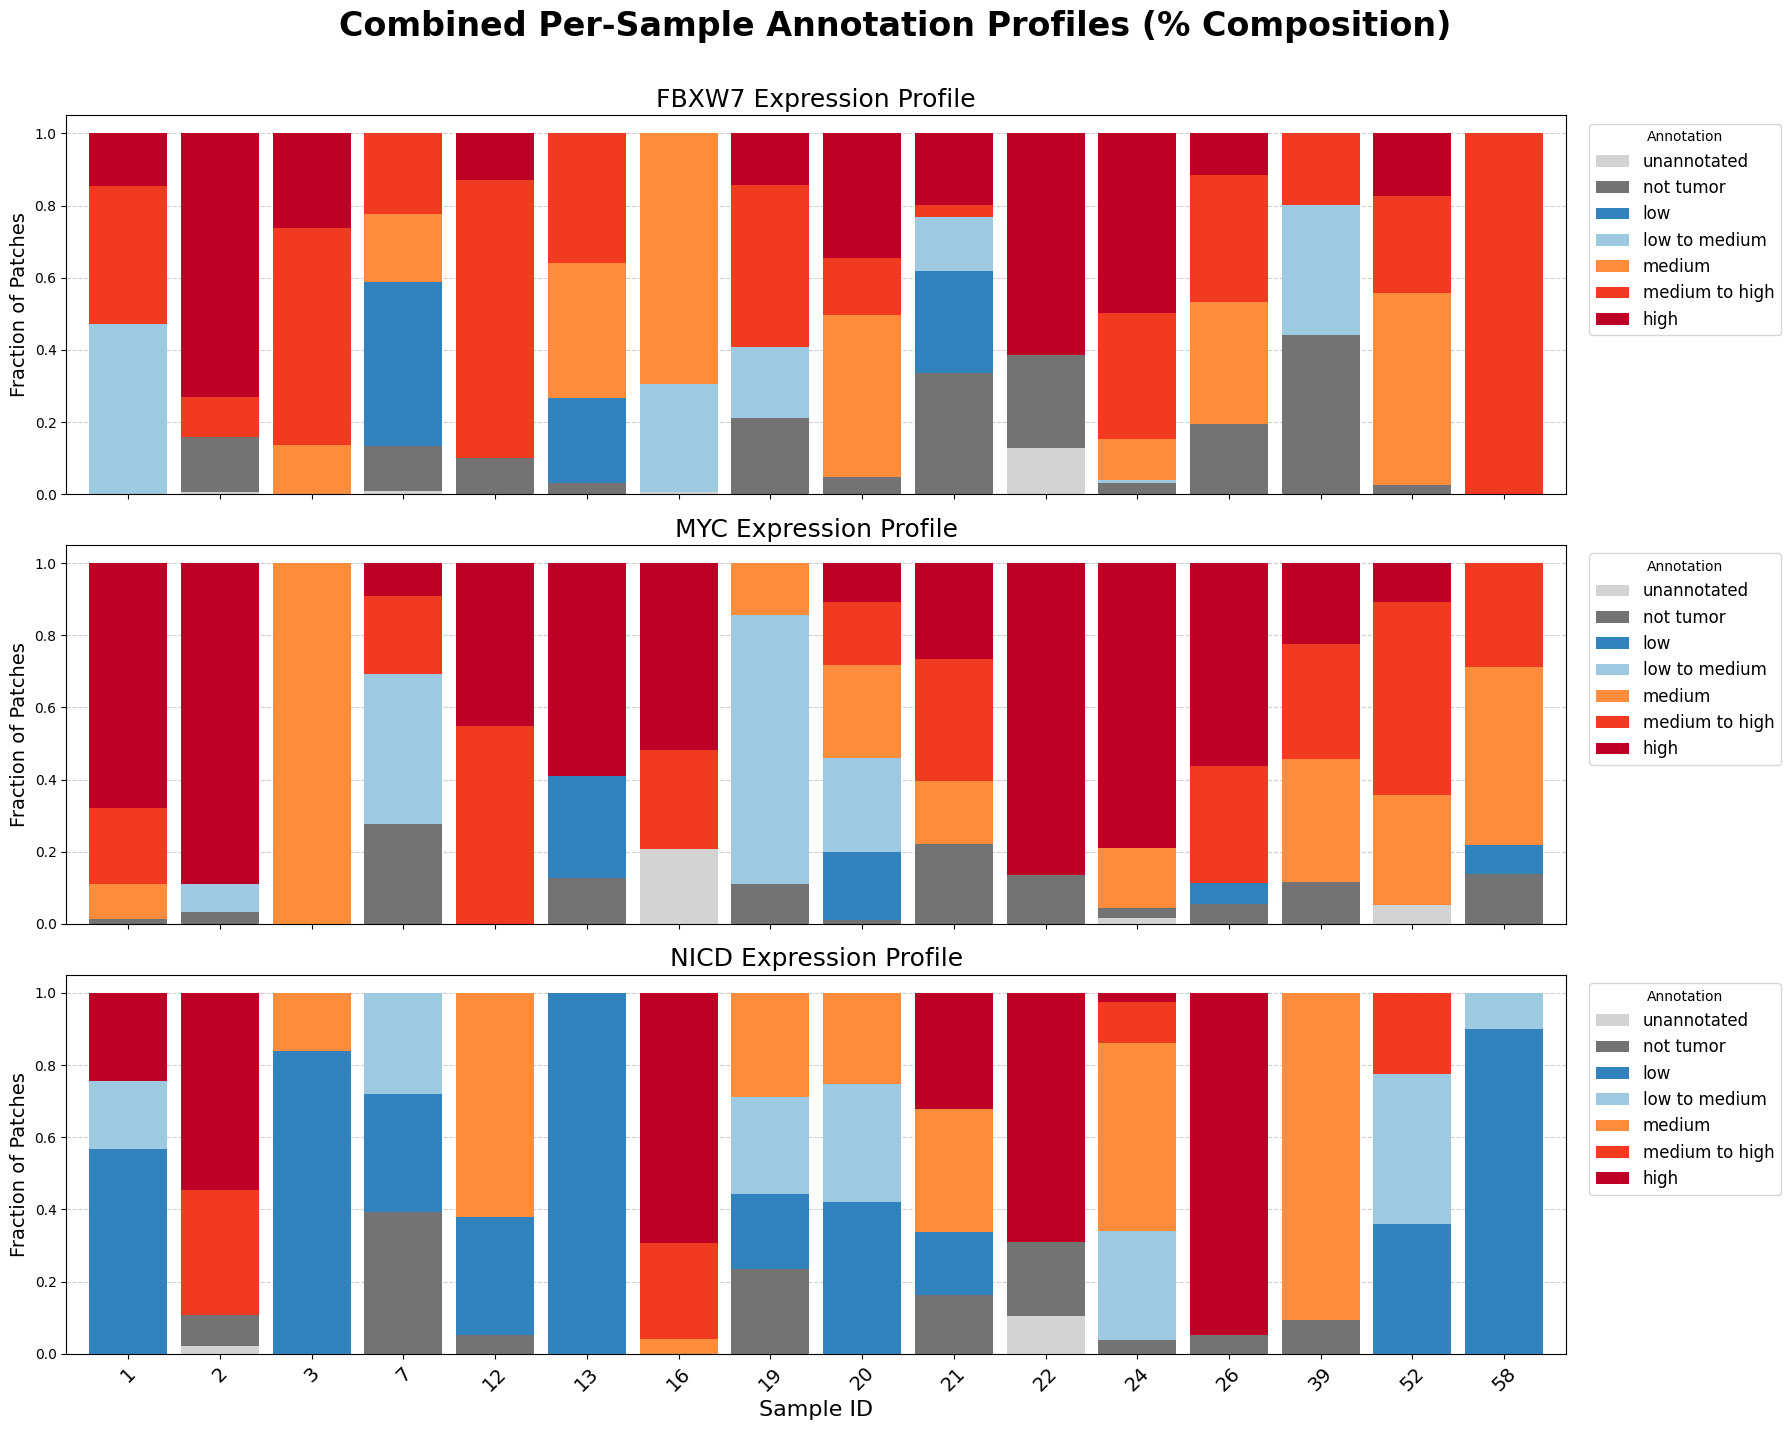


Master visualization saved to: /Users/lollija/phd/fbxw7/plots/combined_per_sample_annotation_profiles_relative.png


In [119]:
import gc
import glob
import os

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd


RESULTS_DIR = "/Users/lollija/phd/fbxw7/results_per_sample"
PLOT_DIR = "/Users/lollija/phd/fbxw7/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

MARKERS = ["FBXW7", "MYC", "NICD"]

ANNOTATION_COLORS = {
    "unannotated": "#d3d3d3",
    "not tumor": "#737373",
    "low": "#3182bd",
    "low to medium": "#9ecae1",
    "medium": "#fd8d3c",
    "medium to high": "#f03b20",
    "high": "#bd0026",
    "mixed": "#756bb1",
}


def numeric_sort_key(value):
    text = str(value)
    return (0, int(text)) if text.isdigit() else (1, text)


def sample_from_path(path, marker):
    filename = os.path.basename(path)
    return filename.replace("adata_", "").replace(f"_{marker}.h5ad", "")


def clean_annotations(series):
    values = series.astype(str).fillna("unannotated")
    values = values.replace({"nan": "unannotated", "None": "unannotated"})
    return values.where(values.isin(ANNOTATION_COLORS), "unannotated")


marker_data_dict = {}
marker_abs_dict = {}
all_samples = set()

for marker in MARKERS:
    search_pattern = os.path.join(RESULTS_DIR, f"adata_*_{marker}.h5ad")
    adata_paths = sorted(glob.glob(search_pattern), key=lambda p: numeric_sort_key(sample_from_path(p, marker)))

    if not adata_paths:
        print(f"Missing per-sample files for {marker}: {search_pattern}")
        continue

    print(f"Processing per-sample annotations for {marker}...")
    marker_rows = []

    for adata_path in adata_paths:
        fallback_sample = sample_from_path(adata_path, marker)
        adata = ad.read_h5ad(adata_path)

        if "sample" in adata.obs.columns and len(adata.obs["sample"]) > 0:
            sample_id = str(adata.obs["sample"].astype(str).iloc[0])
        else:
            sample_id = fallback_sample

        if "annotation" not in adata.obs.columns:
            print(f"No annotation column in {os.path.basename(adata_path)}; using unannotated.")
            annotations = pd.Series(["unannotated"] * adata.n_obs)
        else:
            annotations = clean_annotations(adata.obs["annotation"])

        marker_rows.append(
            pd.DataFrame(
                {
                    "sample": sample_id,
                    "annotation": annotations.values,
                }
            )
        )
        all_samples.add(sample_id)

        del adata
        gc.collect()

    if not marker_rows:
        continue

    df = pd.concat(marker_rows, ignore_index=True)
    annot_cols = [label for label in ANNOTATION_COLORS if label in set(df["annotation"])]

    abs_counts = pd.crosstab(df["sample"], df["annotation"])
    abs_counts = abs_counts.reindex(columns=annot_cols, fill_value=0)
    rel_counts = abs_counts.div(abs_counts.sum(axis=1), axis=0)

    marker_abs_dict[marker] = abs_counts
    marker_data_dict[marker] = rel_counts

    summary_table = abs_counts.T
    summary_table["Total_Patches"] = summary_table.sum(axis=1)
    print(f"\nPatch Count Summary per Per-Sample Annotation ({marker}):\n")
    print(summary_table.to_string())
    print("")


if not marker_data_dict:
    print("No per-sample annotation data available to plot.")
else:
    sorted_samples = sorted(all_samples, key=numeric_sort_key)
    present_markers = [marker for marker in MARKERS if marker in marker_data_dict]
    num_markers = len(present_markers)
    fig, axes = plt.subplots(
        nrows=num_markers,
        ncols=1,
        figsize=(18, 5 * num_markers),
        sharex=True,
    )

    if num_markers == 1:
        axes = [axes]

    fig.suptitle(
        "Combined Per-Sample Annotation Profiles (% Composition)",
        fontsize=24,
        fontweight="bold",
        y=0.95,
    )

    for idx, marker in enumerate(present_markers):
        ax = axes[idx]
        rel_counts = marker_data_dict[marker].reindex(sorted_samples, fill_value=0)
        ordered_cols = [label for label in ANNOTATION_COLORS if label in rel_counts.columns]
        rel_counts = rel_counts[ordered_cols]
        plot_colors = [ANNOTATION_COLORS[label] for label in ordered_cols]

        rel_counts.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=plot_colors,
            width=0.85,
            edgecolor="none",
        )

        ax.set_title(f"{marker} Expression Profile", fontsize=18)
        ax.set_ylabel("Fraction of Patches", fontsize=14)
        ax.legend(
            title="Annotation",
            bbox_to_anchor=(1.01, 1),
            loc="upper left",
            fontsize=12,
        )
        ax.yaxis.grid(True, linestyle="--", alpha=0.6)
        ax.set_axisbelow(True)

    axes[-1].set_xlabel("Sample ID", fontsize=16)
    axes[-1].tick_params(axis="x", rotation=45, labelsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    out_path = os.path.join(PLOT_DIR, "combined_per_sample_annotation_profiles_relative.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"\nMaster visualization saved to: {out_path}")
